In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time


# ----------------------------
# 1. Edge setup
# ----------------------------
edge_options = webdriver.EdgeOptions()
# edge_options.add_argument("--headless")  # optional
edge_options.add_argument("--disable-notifications")

driver = webdriver.Edge(options=edge_options)

url = "https://www.softwareadvice.com/machine-learning/mysql-profile/reviews/"


try:
    driver.get(url)

    wait = WebDriverWait(driver, 20)

    # ----------------------------
    # 2. Cookie popup (optional)
    # ----------------------------
    try:
        cookie_btn = WebDriverWait(driver, 5).until(
            EC.element_to_be_clickable((By.ID, "accept-recommended-btn-handler"))
        )
        cookie_btn.click()
        time.sleep(2)
    except:
        pass

    # ----------------------------
    # 3. Scroll to trigger lazy loading
    # ----------------------------
    print("Scrolling page to load reviews...")
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(3)

    # ----------------------------
    # 4. Wait until at least SOME real text appears
    # ----------------------------
    print("Waiting for review text to hydrate...")

    def reviews_loaded(d):
        pros = d.find_elements(By.CSS_SELECTOR, '[data-testid="review-pros-text"]')
        return any(p.get_attribute("innerText").strip() != "" for p in pros)

    wait.until(reviews_loaded)

    # ----------------------------
    # 5. Extract elements
    # ----------------------------
    pros_elements = driver.find_elements(By.CSS_SELECTOR, '[data-testid="review-pros-text"]')
    cons_elements = driver.find_elements(By.CSS_SELECTOR, '[data-testid="review-cons-text"]')

    print(f"\nFound {len(pros_elements)} review containers\n")

    reviews = []

    # ----------------------------
    # 6. Extract clean text
    # ----------------------------
    for i in range(min(len(pros_elements), len(cons_elements))):

        pros = pros_elements[i].get_attribute("innerText").strip()
        cons = cons_elements[i].get_attribute("innerText").strip()

        # skip empty pairs
        if not pros and not cons:
            continue

        reviews.append({
            "pros": pros,
            "cons": cons
        })

        print(f"--- Review {len(reviews)} ---")
        print("PROS:", pros)
        print("CONS:", cons)
        print("-" * 50)

    print(f"\n✅ Successfully extracted {len(reviews)} valid reviews")

finally:
    driver.quit()

In [60]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
import time
import json


# ----------------------------
# Setup Edge
# ----------------------------
edge_options = webdriver.EdgeOptions()
# edge_options.add_argument("--headless")
edge_options.add_argument("--disable-notifications")

driver = webdriver.Edge(options=edge_options)

url = "https://www.softwareadvice.com/construction/qb-desktop-enterprise-profile/reviews/"
driver.get(url)

wait = WebDriverWait(driver, 20)

all_reviews = []

MAX_PAGES = 100   # 🔥 LIMIT HERE


try:
    # ----------------------------
    # Cookie popup
    # ----------------------------
    try:
        WebDriverWait(driver, 5).until(
            lambda d: d.find_element(By.ID, "accept-recommended-btn-handler")
        ).click()
        time.sleep(2)
    except:
        pass


    page = 1

    while page <= MAX_PAGES:

        print(f"\n================ PAGE {page} / {MAX_PAGES} ================\n")

        # scroll to load reviews
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(2)

        # wait for reviews
        wait.until(
            lambda d: len(d.find_elements(By.CSS_SELECTOR, '[data-testid="review-pros-text"]')) > 0
        )

        # ----------------------------
        # extract data
        # ----------------------------
        names = driver.find_elements(By.CSS_SELECTOR, '[data-testid="reviewer-first-name"]')
        titles = driver.find_elements(By.CSS_SELECTOR, 'p.text-2xl.font-bold.text-spacecadet-90')
        pros = driver.find_elements(By.CSS_SELECTOR, '[data-testid="review-pros-text"]')
        cons = driver.find_elements(By.CSS_SELECTOR, '[data-testid="review-cons-text"]')

        count = min(len(names), len(titles), len(pros), len(cons))

        for i in range(count):

            review = {
                "title": titles[i].text.strip(),
                "name": names[i].text.strip(),
                "pros": pros[i].get_attribute("innerText").strip(),
                "cons": cons[i].get_attribute("innerText").strip()
            }

            if review["title"] or review["pros"] or review["cons"]:
                all_reviews.append(review)

        # ----------------------------
        # STOP IF LAST PAGE LIMIT REACHED
        # ----------------------------
        if page >= MAX_PAGES:
            print("\n🚀 Reached page limit. Stopping.")
            break

        # ----------------------------
        # click NEXT
        # ----------------------------
        try:
            next_btn = driver.find_element(By.CSS_SELECTOR, '[data-testid="next-button"]')

            if not next_btn.is_enabled():
                print("\n🚫 Next button disabled. Stopping.")
                break

            driver.execute_script("arguments[0].click();", next_btn)

            page += 1
            time.sleep(4)

        except Exception:
            print("\n🚫 Next button not found. Stopping.")
            break


finally:
    driver.quit()


# ----------------------------
# SAVE JSON
# ----------------------------
final_output = {
    "product": "QuickBooks",
    "reviews": all_reviews
}

with open("C:/Users/kawka/Downloads/QuickBooks.json", "w", encoding="utf-8") as f:
    json.dump(final_output, f, indent=4, ensure_ascii=False)

print(f"\n\n✅ Saved {len(all_reviews)} reviews from {page-1} pages")


================ PAGE 1 / 100 ================


================ PAGE 2 / 100 ================


================ PAGE 3 / 100 ================


================ PAGE 4 / 100 ================


================ PAGE 5 / 100 ================


================ PAGE 6 / 100 ================


================ PAGE 7 / 100 ================


================ PAGE 8 / 100 ================


================ PAGE 9 / 100 ================


================ PAGE 10 / 100 ================


================ PAGE 11 / 100 ================


================ PAGE 12 / 100 ================


================ PAGE 13 / 100 ================


================ PAGE 14 / 100 ================


================ PAGE 15 / 100 ================


================ PAGE 16 / 100 ================


================ PAGE 17 / 100 ================


================ PAGE 18 / 100 ================


================ PAGE 19 / 100 ================


================ PAGE 20 / 100 ================


========

In [64]:
import os
import json
from glob import glob

folder_path = r"C:\Users\kawka\Downloads\CLAP_DATASET_NEW"
output_file = os.path.join(folder_path, "combined.json")

all_data = []

for file_path in glob(os.path.join(folder_path, "*.json")):
    with open(file_path, "r", encoding="utf-8") as f:
        try:
            data = json.load(f)

            # If JSON is a list, extend
            if isinstance(data, list):
                all_data.extend(data)
            else:
                # If JSON is a dict, append directly (no wrapper)
                all_data.append(data)

        except json.JSONDecodeError as e:
            print(f"Skipping invalid JSON: {file_path} ({e})")

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(all_data, f, indent=2, ensure_ascii=False)

print(f"Combined {len(glob(os.path.join(folder_path, '*.json')))} files into {output_file}")

Combined 16 files into C:\Users\kawka\Downloads\CLAP_DATASET_NEW\combined.json


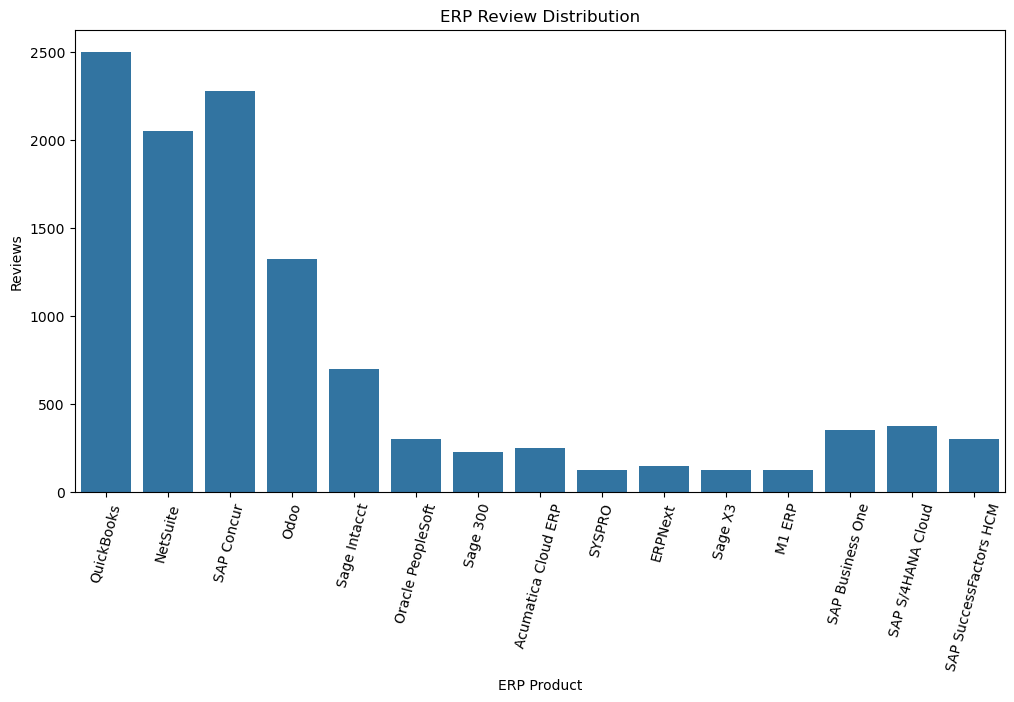

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

data = {
    "ERP Product": [
        "QuickBooks", "NetSuite", "SAP Concur", "Odoo", "Sage Intacct",
        "Oracle PeopleSoft", "Sage 300", "Acumatica Cloud ERP", "SYSPRO",
        "ERPNext", "Sage X3", "M1 ERP", "SAP Business One",
        "SAP S/4HANA Cloud", "SAP SuccessFactors HCM"
    ],
    "Reviews": [
        2500, 2050, 2275, 1325, 700,
        300, 225, 250, 125,
        144, 125, 125, 350,
        375, 300
    ]
}

df = pd.DataFrame(data)

plt.figure(figsize=(12,6))
sns.barplot(data=df, x="ERP Product", y="Reviews")
plt.xticks(rotation=75)
plt.title("ERP Review Distribution")
plt.show()